# 🎯 Eye Tracking CNN: Klasifikasi Arah Pandangan Mata

**Notebook ini mendemonstrasikan pembuatan dan pelatihan Convolutional Neural Network (CNN) untuk mengklasifikasikan arah pandangan mata ke dalam 3 kategori: Kiri, Kanan, dan Tengah.**

---

## 📋 Daftar Isi
1. [Konsep CNN](#1-konsep-cnn-untuk-eye-tracking)
2. [Setup & Konfigurasi](#2-setup--konfigurasi)
3. [Load Dataset](#3-load-dataset)
4. [Train/Test Split](#4-traintest-split)
5. [Data Augmentation](#5-data-augmentation)
6. [Arsitektur CNN](#6-arsitektur-cnn)
7. [Training Model](#7-training-model)
8. [Evaluasi & Visualisasi](#8-evaluasi--visualisasi)
9. [Prediksi pada Data Baru](#9-prediksi-pada-data-baru)

---

## 1. Konsep CNN untuk Eye Tracking

### Mengapa CNN?

CNN (Convolutional Neural Network) adalah arsitektur jaringan saraf yang dirancang khusus untuk memproses data dengan struktur grid, seperti gambar.

### Komponen Utama:

| Layer | Fungsi | Analogi |
|-------|--------|---------|
| **Conv2D** | Mendeteksi fitur lokal (tepi, sudut, tekstur) | Kacamata detektif yang melihat pola |
| **MaxPooling2D** | Mereduksi dimensi spasial | Menyederhanakan gambar tanpa kehilangan esensi |
| **BatchNormalization** | Normalisasi output agar training stabil | Penyetabil suhu ruangan |
| **Dropout** | Mematikan neuron acak selama training | Ujian pop quiz untuk mencegah hafalan |
| **Dense + Softmax** | Klasifikasi akhir | Juri yang memberikan skor akhir |

### Alur Kerja:
```
Input (64x64 grayscale) → Conv → Pool → Conv → Pool → Conv → Pool → Flatten → Dense → Output (3 kelas)
```

In [1]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  ⚠️  INSTALL DEPENDENCY (Jalankan cell ini JIKA mendapat error import)      ║
# ║                                                                             ║
# ║  Cell ini menginstall package yang diperlukan:                              ║
# ║  - tensorflow : Framework deep learning                                     ║
# ║  - ipywidgets : Widget interaktif (opsional)                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

!pip install -q tensorflow ipywidgets

# Verifikasi instalasi
import importlib
packages = ['tensorflow', 'numpy', 'matplotlib', 'sklearn', 'seaborn', 'PIL']

print("📦 Status Package:")
for pkg in packages:
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, '__version__', 'unknown')
        print(f"  ✅ {pkg:<15} v{ver}")
    except ImportError:
        print(f"  ❌ {pkg:<15} BELUM TERINSTALL")

print("\n✅ Instalasi selesai! Restart kernel jika diperlukan.")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.35.0 which is incompatible.


📦 Status Package:
  ✅ tensorflow      v2.21.0
  ✅ numpy           v1.26.4
  ✅ matplotlib      v3.9.2
  ✅ sklearn         v1.5.1
  ✅ seaborn         v0.13.2
  ✅ PIL             v10.4.0

✅ Instalasi selesai! Restart kernel jika diperlukan.


> 💡 **Tips:** Jika setelah install masih error, restart kernel dengan menu **Kernel → Restart** lalu jalankan semua cell dari awal.
> 
> Alternatif install via terminal:
> ```bash
> pip install tensorflow numpy matplotlib scikit-learn seaborn pillow
> ```

---

## 2. Setup & Konfigurasi

**Import library yang diperlukan dan definisikan konstanta konfigurasi.**

In [2]:
# ─── IMPORT LIBRARY ───────────────────────────────────────────────────────────
import numpy as np
import os

try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
    from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
    from tensorflow.keras.utils import plot_model
    print(f"✅ TensorFlow {tf.__version__} berhasil di-import!")
except ImportError as e:
    print("❌ ERROR: TensorFlow belum terinstall!")
    print("\n📋 CARA MENGATASI:")
    print("   1. Jalankan cell 'INSTALL DEPENDENCY' di atas")
    print("   2. Atau install via terminal: pip install tensorflow")
    print("   3. Restart kernel setelah install")
    raise

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output

print("✅ Semua library berhasil di-import!")

✅ TensorFlow 2.21.0 berhasil di-import!
✅ Semua library berhasil di-import!


In [3]:
# ─── KONFIGURASI ──────────────────────────────────────────────────────────────
IMG_SIZE    = 64                          # Ukuran gambar input (64x64 piksel)
DATASET_DIR = "dataset"                   # Folder dataset
MODEL_PATH  = "model/eye_tracker.h5"      # Path untuk menyimpan model
CATEGORIES  = ["kiri", "kanan", "tengah"]  # Label kelas (index 0, 1, 2)
EPOCHS      = 30                          # Maksimum epoch training
BATCH_SIZE  = 32                          # Jumlah sampel per batch

# Buat folder model jika belum ada
os.makedirs("model", exist_ok=True)

print("📋 Konfigurasi:")
print(f"   Ukuran gambar : {IMG_SIZE}x{IMG_SIZE}")
print(f"   Dataset       : {DATASET_DIR}")
print(f"   Kelas         : {CATEGORIES}")
print(f"   Epoch         : {EPOCHS}")
print(f"   Batch size    : {BATCH_SIZE}")

📋 Konfigurasi:
   Ukuran gambar : 64x64
   Dataset       : dataset
   Kelas         : ['kiri', 'kanan', 'tengah']
   Epoch         : 30
   Batch size    : 32


---

## 3. Load Dataset

**Dataset terdiri dari gambar grayscale berukuran 64x64 piksel dalam format `.npy` (NumPy array), terorganisir dalam 3 folder berdasarkan label kelasnya.**

### Struktur Folder Dataset:
```
dataset/
├── kiri/        ← Gambar mata melihat ke kiri   (label=0)
│   ├── 001.npy
│   ├── 002.npy
│   └── ...
├── kanan/       ← Gambar mata melihat ke kanan  (label=1)
│   ├── 001.npy
│   └── ...
└── tengah/      ← Gambar mata melihat ke tengah (label=2)
    ├── 001.npy
    └── ...
```

📂 Memuat dataset...

📁 KIRI (label=0): 1143 sampel

📁 KANAN (label=1): 1357 sampel

📁 TENGAH (label=2): 1566 sampel

📊 STATISTIK DATASET:
   Total sampel : 4066
   Shape input  : (4066, 64, 64, 1)
   Distribusi   : [1143 1357 1566] (kiri, kanan, tengah)


C:\Users\HP\AppData\Local\Temp\ipykernel_13380\461690175.py:40: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


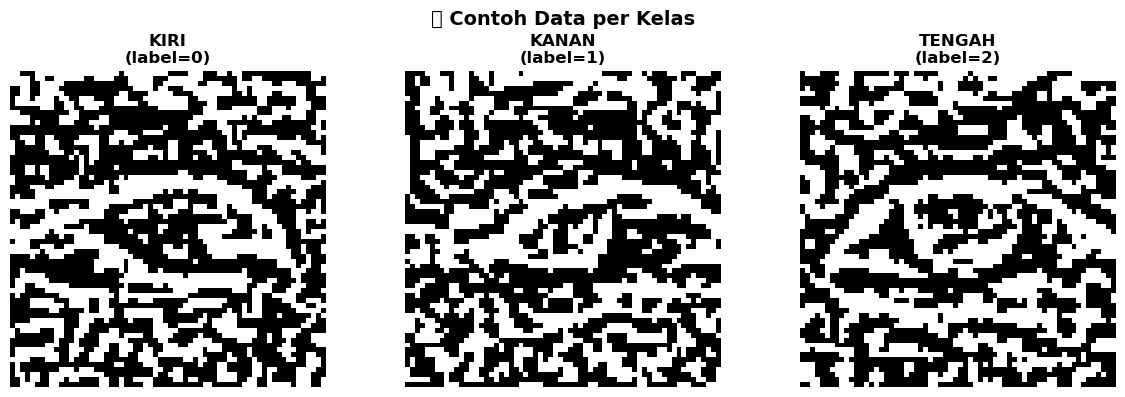

In [4]:
# ─── LOAD DATA ────────────────────────────────────────────────────────────────
print("📂 Memuat dataset...")
print("=" * 50)

X, y = [], []  # X = data gambar, y = label

for label_idx, category in enumerate(CATEGORIES):
    folder = os.path.join(DATASET_DIR, category)
    files  = [f for f in os.listdir(folder) if f.endswith(".npy")]
    print(f"\n📁 {category.upper()} (label={label_idx}): {len(files)} sampel")

    for fname in files:
        img = np.load(os.path.join(folder, fname))  # Shape: (64, 64)
        X.append(img)
        y.append(label_idx)

# Konversi ke NumPy array
X = np.array(X)  # Shape: (N, 64, 64)
y = np.array(y)  # Shape: (N,)

# CNN mengharapkan format (batch, height, width, channels)
# Tambahkan dimensi channel: (N, 64, 64) → (N, 64, 64, 1)
X = X[..., np.newaxis]

print("\n" + "=" * 50)
print(f"📊 STATISTIK DATASET:")
print(f"   Total sampel : {len(X)}")
print(f"   Shape input  : {X.shape}")
print(f"   Distribusi   : {np.bincount(y)} (kiri, kanan, tengah)")

# ─── VISUALISASI CONTOH DATA ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for idx, (cat, ax) in enumerate(zip(CATEGORIES, axes)):
    # Cari gambar pertama untuk setiap kelas
    sample_idx = np.where(y == idx)[0][0]
    ax.imshow(X[sample_idx].squeeze(), cmap='gray')
    ax.set_title(f"{cat.upper()}\n(label={idx})", fontsize=12, fontweight='bold')
    ax.axis('off')
plt.suptitle("📷 Contoh Data per Kelas", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 4. Train/Test Split

**Membagi dataset menjadi data training (80%) dan data testing (20%) dengan stratified sampling agar proporsi kelas seimbang.**

| Parameter | Nilai | Penjelasan |
|-----------|-------|------------|
| `test_size` | 0.2 | 20% data untuk evaluasi |
| `stratify` | y | Proporsi kelas sama di train & test |
| `random_state` | 42 | Agar hasil reproducible |

✅ Dataset berhasil dibagi!
   📗 Training : 3252 sampel (80.0%)
   📙 Testing  : 814 sampel (20.0%)

Distribusi Training : [ 914 1085 1253]
Distribusi Testing  : [229 272 313]


C:\Users\HP\AppData\Local\Temp\ipykernel_13380\2598935285.py:34: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


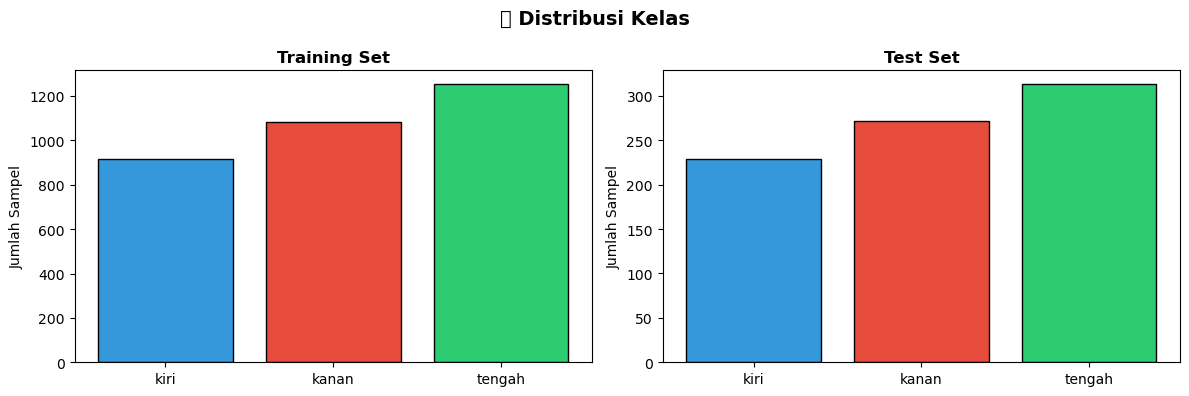

In [5]:
# ─── TRAIN / TEST SPLIT ───────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

print("✅ Dataset berhasil dibagi!")
print(f"   📗 Training : {len(X_train)} sampel ({len(X_train)/len(X)*100:.1f}%)")
print(f"   📙 Testing  : {len(X_test)} sampel ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nDistribusi Training : {np.bincount(y_train)}")
print(f"Distribusi Testing  : {np.bincount(y_test)}")

# Visualisasi distribusi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#3498db', '#e74c3c', '#2ecc71']
x_pos = np.arange(len(CATEGORIES))

ax1.bar(x_pos, np.bincount(y_train), color=colors, edgecolor='black')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(CATEGORIES)
ax1.set_title("Training Set", fontweight='bold')
ax1.set_ylabel("Jumlah Sampel")

ax2.bar(x_pos, np.bincount(y_test), color=colors, edgecolor='black')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(CATEGORIES)
ax2.set_title("Test Set", fontweight='bold')
ax2.set_ylabel("Jumlah Sampel")

plt.suptitle("📊 Distribusi Kelas", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 5. Data Augmentation

**Augmentasi data meningkatkan variasi data training tanpa mengumpulkan data baru. Ini membantu model lebih robust terhadap variasi posisi kepala dan pencahayaan.**

### Teknik Augmentasi yang Digunakan:

| Teknik | Range | Simulasi |
|--------|-------|----------|
| Rotation | ±10° | Kepala sedikit miring |
| Width Shift | ±10% | Posisi horizontal berubah |
| Height Shift | ±10% | Posisi vertikal berubah |
| Zoom | ±10% | Jarak ke kamera berubah |
| Brightness | 0.7 - 1.3x | Variasi pencahayaan |

> ⚠️ **Horizontal Flip dinonaktifkan!** Karena kiri ≠ kanan untuk klasifikasi ini.

✅ Data Augmentation siap!


C:\Users\HP\AppData\Local\Temp\ipykernel_13380\3778914916.py:35: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


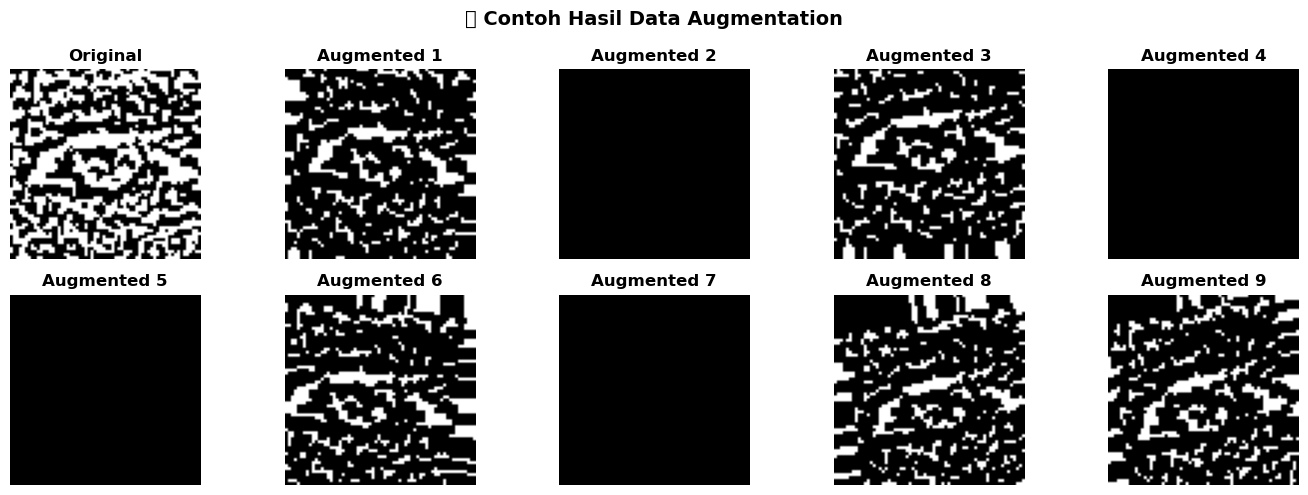

In [6]:
# ─── DATA AUGMENTATION ────────────────────────────────────────────────────────
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,           # Putar ±10 derajat
    width_shift_range=0.1,       # Geser horizontal ±10%
    height_shift_range=0.1,      # Geser vertikal ±10%
    zoom_range=0.1,              # Zoom in/out ±10%
    horizontal_flip=False,       # JANGAN flip! Kiri ≠ Kanan
    brightness_range=[0.7, 1.3]  # Variasi kecerahan
)
datagen.fit(X_train)

print("✅ Data Augmentation siap!")

# ─── VISUALISASI AUGMENTASI ──────────────────────────────────────────────────
# Ambil 1 gambar dan lihat variasi augmentasinya
sample_image = X_train[0:1]  # Ambil 1 gambar

fig, axes = plt.subplots(2, 5, figsize=(14, 5))
axes = axes.flatten()

# Gambar original
axes[0].imshow(sample_image.squeeze(), cmap='gray')
axes[0].set_title("Original", fontweight='bold')
axes[0].axis('off')

# 9 variasi augmented
aug_iter = datagen.flow(sample_image, batch_size=1)
for i in range(1, 10):
    aug_img = next(aug_iter)[0]
    axes[i].imshow(aug_img.squeeze(), cmap='gray')
    axes[i].set_title(f"Augmented {i}", fontweight='bold')
    axes[i].axis('off')

plt.suptitle("🔄 Contoh Hasil Data Augmentation", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 6. Arsitektur CNN

**Model Sequential: data mengalir linear dari satu layer ke layer berikutnya.**

### Blok Konvolusi:

```
┌─────────────────────────────────────────────────────────────┐
│  Input: (64, 64, 1) - Grayscale image                       │
│                                                             │
│  ┌─────────────┐   ┌─────────────┐   ┌─────────────┐       │
│  │ Conv2D: 32  │ → │ BatchNorm   │ → │ MaxPool     │ → 31x31
│  │ (3x3)       │   │             │   │ (2x2)       │       │
│  └─────────────┘   └─────────────┘   └─────────────┘       │
│         ↓                                                   │
│  ┌─────────────┐   ┌─────────────┐   ┌─────────────┐       │
│  │ Conv2D: 64  │ → │ BatchNorm   │ → │ MaxPool     │ → 14x14
│  │ (3x3)       │   │             │   │ (2x2)       │       │
│  └─────────────┘   └─────────────┘   └─────────────┘       │
│         ↓                                                   │
│  ┌─────────────┐   ┌─────────────┐   ┌─────────────┐       │
│  │ Conv2D: 128 │ → │ BatchNorm   │ → │ MaxPool     │ → 6x6  │
│  │ (3x3)       │   │             │   │ (2x2)       │       │
│  └─────────────┘   └─────────────┘   └─────────────┘       │
│                                                             │
│  ┌─────────────┐   ┌─────────────┐   ┌─────────────┐       │
│  │ Flatten     │ → │ Dense: 128  │ → │ Dropout 0.5 │       │
│  │ (4608)      │   │ (ReLU)      │   │             │       │
│  └─────────────┘   └─────────────┘   └─────────────┘       │
│                           ↓                                 │
│                   ┌─────────────┐                           │
│                   │ Dense: 3    │                           │
│                   │ (Softmax)   │ → Probabilitas [kiri, kanan, tengah]
│                   └─────────────┘                           │
└─────────────────────────────────────────────────────────────┘
```

In [7]:
# ─── ARSITEKTUR CNN ───────────────────────────────────────────────────────────
def build_model(input_shape=(IMG_SIZE, IMG_SIZE, 1), num_classes=3):
    """
    Membangun model CNN Sequential untuk klasifikasi arah pandangan mata.
    
    Blok 1 (Conv 32):
      - 32 filter 3x3: deteksi fitur dasar (tepi pupil, iris)
      - BatchNormalization: normalisasi output
      - MaxPooling: 64x64 → 31x31
    
    Blok 2 (Conv 64):
      - 64 filter: pola lebih kompleks
      - MaxPooling: 31x31 → 14x14
      
    Blok 3 (Conv 128):
      - 128 filter: pola high-level (arah pandang)
      - MaxPooling: 14x14 → 6x6
      
    Klasifikasi:
      - Flatten: 3D → 1D (6x6x128 = 4608)
      - Dense(128): fully-connected
      - Dropout(0.5): 50% neuron dimatikan (cegah overfitting)
      - Dense(3, softmax): output probabilitas
    """
    model = models.Sequential([
        # ═══════════════════════════════════════════
        # BLOK KONVOLUSI 1
        # ═══════════════════════════════════════════
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1'),
        layers.BatchNormalization(name='bn1'),
        layers.MaxPooling2D((2, 2), name='pool1'),

        # ═══════════════════════════════════════════
        # BLOK KONVOLUSI 2
        # ═══════════════════════════════════════════
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
        layers.BatchNormalization(name='bn2'),
        layers.MaxPooling2D((2, 2), name='pool2'),

        # ═══════════════════════════════════════════
        # BLOK KONVOLUSI 3
        # ═══════════════════════════════════════════
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3'),
        layers.BatchNormalization(name='bn3'),
        layers.MaxPooling2D((2, 2), name='pool3'),

        # ═══════════════════════════════════════════
        # KLASIFIKASI
        # ═══════════════════════════════════════════
        layers.Flatten(name='flatten'),
        layers.Dense(128, activation='relu', name='dense1'),
        layers.Dropout(0.5, name='dropout'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    return model

# Buat instance model
model = build_model()

# Tampilkan summary arsitektur
print("🏗️  ARSITEKTUR MODEL CNN")
print("=" * 70)
model.summary()

🏗️  ARSITEKTUR MODEL CNN


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,659 (4.36 MB)

 Trainable params: 1,142,211 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
# ─── VISUALISASI ARSITEKTUR (DIAGRAM) ───────────────────────────────────────
# Buat diagram visual arsitektur model
try:
    plot_model(
        model, 
        to_file='model/architecture.png', 
        show_shapes=True, 
        show_layer_names=True,
        dpi=100,
        expand_nested=True
    )
    print("✅ Diagram arsitektur disimpan ke: model/architecture.png")
except Exception as e:
    print(f"⚠️  Tidak dapat membuat diagram: {e}")
    print("   (Install graphviz dan pydot jika ingin melihat diagram)")

You must install pydot (`pip install pydot`) for `plot_model` to work.
✅ Diagram arsitektur disimpan ke: model/architecture.png


---

## 7. Training Model

### Konfigurasi Training:

| Parameter | Nilai | Penjelasan |
|-----------|-------|------------|
| **Optimizer** | Adam (lr=0.001) | Optimizer adaptif, cepat konvergen |
| **Loss Function** | sparse_categorical_crossentropy | Cocok untuk label integer (0,1,2) |
| **Metrics** | accuracy | Persentase prediksi benar |
| **Early Stopping** | patience=5 | Hentikan jika val_loss tidak membaik 5 epoch |
| **Model Checkpoint** | save_best_only | Simpan model terbaik berdasarkan val_accuracy |

In [9]:
# ─── COMPILE MODEL ────────────────────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model berhasil di-compile!")
print("\n📋 Konfigurasi Training:")
print(f"   Optimizer : Adam (lr=0.001)")
print(f"   Loss      : sparse_categorical_crossentropy")
print(f"   Metrics   : accuracy")

✅ Model berhasil di-compile!

📋 Konfigurasi Training:
   Optimizer : Adam (lr=0.001)
   Loss      : sparse_categorical_crossentropy
   Metrics   : accuracy


In [10]:
# ─── CALLBACKS ────────────────────────────────────────────────────────────────
callbacks = [
    # EarlyStopping: Hentikan training jika val_loss tidak membaik selama 5 epoch
    # - Memulihkan weights terbaik (restore_best_weights)
    # - Mencegah overfitting dan menghemat waktu
    EarlyStopping(
        monitor='val_loss', 
        patience=5, 
        restore_best_weights=True,
        verbose=1
    ),

    # ModelCheckpoint: Simpan model terbaik berdasarkan val_accuracy
    # - save_best_only: hanya simpan jika performa lebih baik
    ModelCheckpoint(
        MODEL_PATH, 
        monitor='val_accuracy',
        save_best_only=True, 
        verbose=1
    )
]

print("✅ Callbacks siap!")
print("\n🛡️  EarlyStopping   : Berhenti jika val_loss stagnan 5 epoch")
print(f"💾 ModelCheckpoint : Simpan terbaik ke {MODEL_PATH}")

✅ Callbacks siap!

🛡️  EarlyStopping   : Berhenti jika val_loss stagnan 5 epoch
💾 ModelCheckpoint : Simpan terbaik ke model/eye_tracker.h5


In [11]:
# ─── TRAINING ─────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("🚀 MEMULAI TRAINING...")
print("=" * 60)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

print("\n" + "=" * 60)
print("✅ TRAINING SELESAI!")
print("=" * 60)


🚀 MEMULAI TRAINING...
Epoch 1/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.3699 - loss: 3.8512
Epoch 1: val_accuracy improved from None to 0.28133, saving model to model/eye_tracker.h5



Epoch 1: finished saving model to model/eye_tracker.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 24s 188ms/step - accuracy: 0.4047 - loss: 2.2877 - val_accuracy: 0.2813 - val_loss: 21.4994
Epoch 2/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.4596 - loss: 0.9818
Epoch 2: val_accuracy did not improve from 0.28133
102/102 ━━━━━━━━━━━━━━━━━━━━ 19s 187ms/step - accuracy: 0.4975 - loss: 0.9339 - val_accuracy: 0.2813 - val_loss: 22.5471
Epoch 3/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.5568 - loss: 0.8342
Epoch 3: val_accuracy did not improve from 0.28133
102/102 ━━━━━━━━━━━━━━━━━━━━ 19s 184ms/step - accuracy: 0.5839 - loss: 0.7980 - val_accuracy: 0.2813 - val_loss: 15.5437
Epoch 4/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.6192 - loss: 0.7399
Epoch 4: val_accuracy improved from 0.28133 to 0.63022, saving model to model/eye_tracker.h5



Epoch 4: finished saving model to model/eye_tracker.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 19s 188ms/step - accuracy: 0.6184 - loss: 0.7503 - val_accuracy: 0.6302 - val_loss: 1.1175
Epoch 5/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.6021 - loss: 0.7515
Epoch 5: val_accuracy improved from 0.63022 to 0.67936, saving model to model/eye_tracker.h5



Epoch 5: finished saving model to model/eye_tracker.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 19s 187ms/step - accuracy: 0.6156 - loss: 0.7396 - val_accuracy: 0.6794 - val_loss: 0.6976
Epoch 6/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.6234 - loss: 0.7252
Epoch 6: val_accuracy did not improve from 0.67936
102/102 ━━━━━━━━━━━━━━━━━━━━ 20s 200ms/step - accuracy: 0.6362 - loss: 0.7034 - val_accuracy: 0.5086 - val_loss: 1.3288
Epoch 7/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.6580 - loss: 0.6423
Epoch 7: val_accuracy did not improve from 0.67936
102/102 ━━━━━━━━━━━━━━━━━━━━ 21s 207ms/step - accuracy: 0.6596 - loss: 0.6365 - val_accuracy: 0.4140 - val_loss: 2.5635
Epoch 8/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.6756 - loss: 0.6177
Epoch 8: val_accuracy did not improve from 0.67936
102/102 ━━━━━━━━━━━━━━━━━━━━ 22s 212ms/step - accuracy: 0.6673 - loss: 0.6224 - val_accuracy: 0.6192 - val_loss: 1.0916
Epoch 9/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 195m

---

## 8. Evaluasi & Visualisasi

**Analisis performa model melalui metrik dan visualisasi.**

In [12]:
# ─── EVALUASI MODEL ───────────────────────────────────────────────────────────
loss, acc = model.evaluate(X_test, y_test, verbose=0)

print("📊 HASIL EVALUASI:")
print("=" * 40)
print(f"✅ Test Accuracy : {acc*100:.2f}%")
print(f"📉 Test Loss     : {loss:.4f}")
print(f"💾 Model disimpan : {MODEL_PATH}")

# ─── PREDIKSI UNTUK CLASSIFICATION REPORT ────────────────────────────────────
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\n" + "=" * 40)
print("📋 CLASSIFICATION REPORT:")
print("=" * 40)
print(classification_report(
    y_test, y_pred_classes, 
    target_names=CATEGORIES,
    digits=4
))

📊 HASIL EVALUASI:
✅ Test Accuracy : 67.94%
📉 Test Loss     : 0.6976
💾 Model disimpan : model/eye_tracker.h5

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        kiri     0.9945    0.7904    0.8808       229
       kanan     1.0000    0.2169    0.3565       272
      tengah     0.5462    1.0000    0.7065       313

    accuracy                         0.6794       814
   macro avg     0.8469    0.6691    0.6479       814
weighted avg     0.8240    0.6794    0.6386       814



C:\Users\HP\AppData\Local\Temp\ipykernel_13380\2139916849.py:24: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_13380\2139916849.py:24: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_13380\2139916849.py:25: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig("model/training_curves.png", dpi=150)
C:\Users\HP\AppData\Local\Temp\ipykernel_13380\2139916849.py:25: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig("model/training_curves.png", dpi=150)
c:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\HP\anaconda3

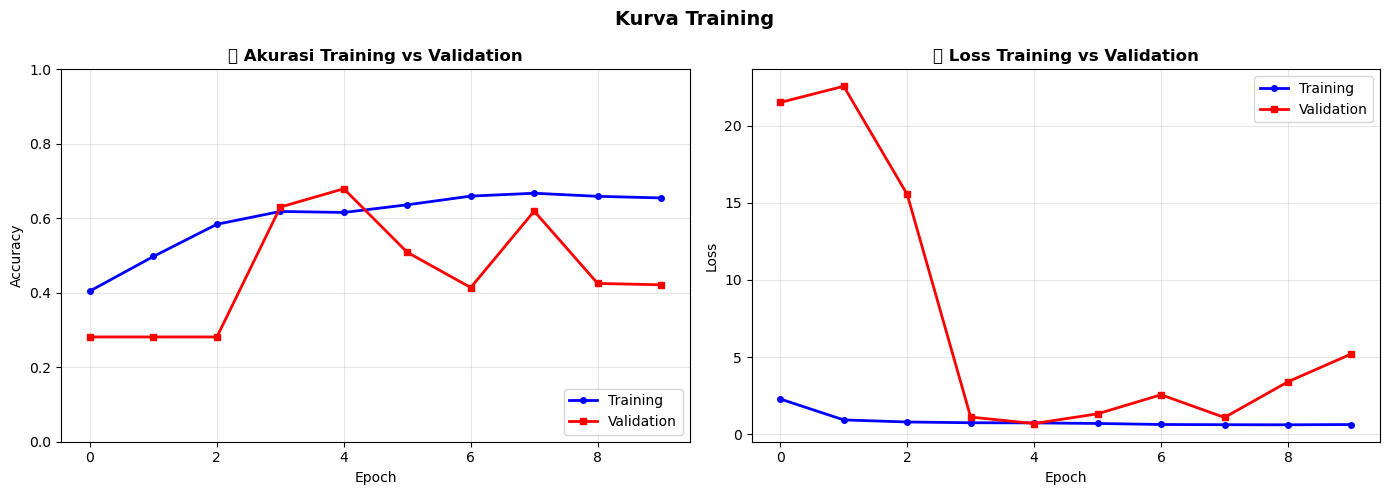

✅ Kurva training disimpan ke: model/training_curves.png


In [13]:
# ─── VISUALISASI 1: TRAINING CURVES ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax1.plot(history.history['accuracy'], 'b-o', label='Training', linewidth=2, markersize=4)
ax1.plot(history.history['val_accuracy'], 'r-s', label='Validation', linewidth=2, markersize=4)
ax1.set_title('📈 Akurasi Training vs Validation', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1])

# Plot Loss
ax2.plot(history.history['loss'], 'b-o', label='Training', linewidth=2, markersize=4)
ax2.plot(history.history['val_loss'], 'r-s', label='Validation', linewidth=2, markersize=4)
ax2.set_title('📉 Loss Training vs Validation', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.suptitle("Kurva Training", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("model/training_curves.png", dpi=150)
plt.show()
print("✅ Kurva training disimpan ke: model/training_curves.png")

C:\Users\HP\AppData\Local\Temp\ipykernel_13380\2741394622.py:19: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_13380\2741394622.py:20: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig("model/confusion_matrix.png", dpi=150)
c:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


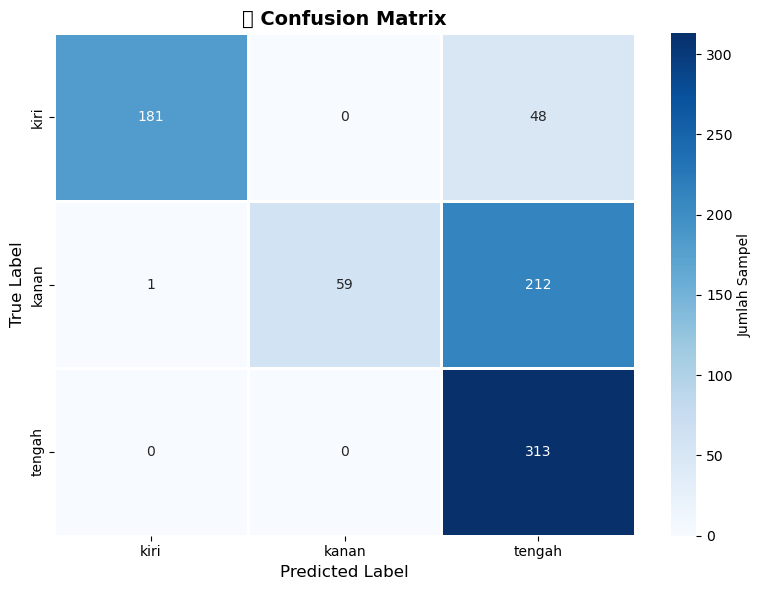

✅ Confusion matrix disimpan ke: model/confusion_matrix.png


In [14]:
# ─── VISUALISASI 2: CONFUSION MATRIX ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=CATEGORIES,
    yticklabels=CATEGORIES,
    cbar_kws={'label': 'Jumlah Sampel'},
    linewidths=1,
    linecolor='white'
)
plt.title('🎯 Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig("model/confusion_matrix.png", dpi=150)
plt.show()
print("✅ Confusion matrix disimpan ke: model/confusion_matrix.png")

C:\Users\HP\AppData\Local\Temp\ipykernel_13380\2974096441.py:50: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


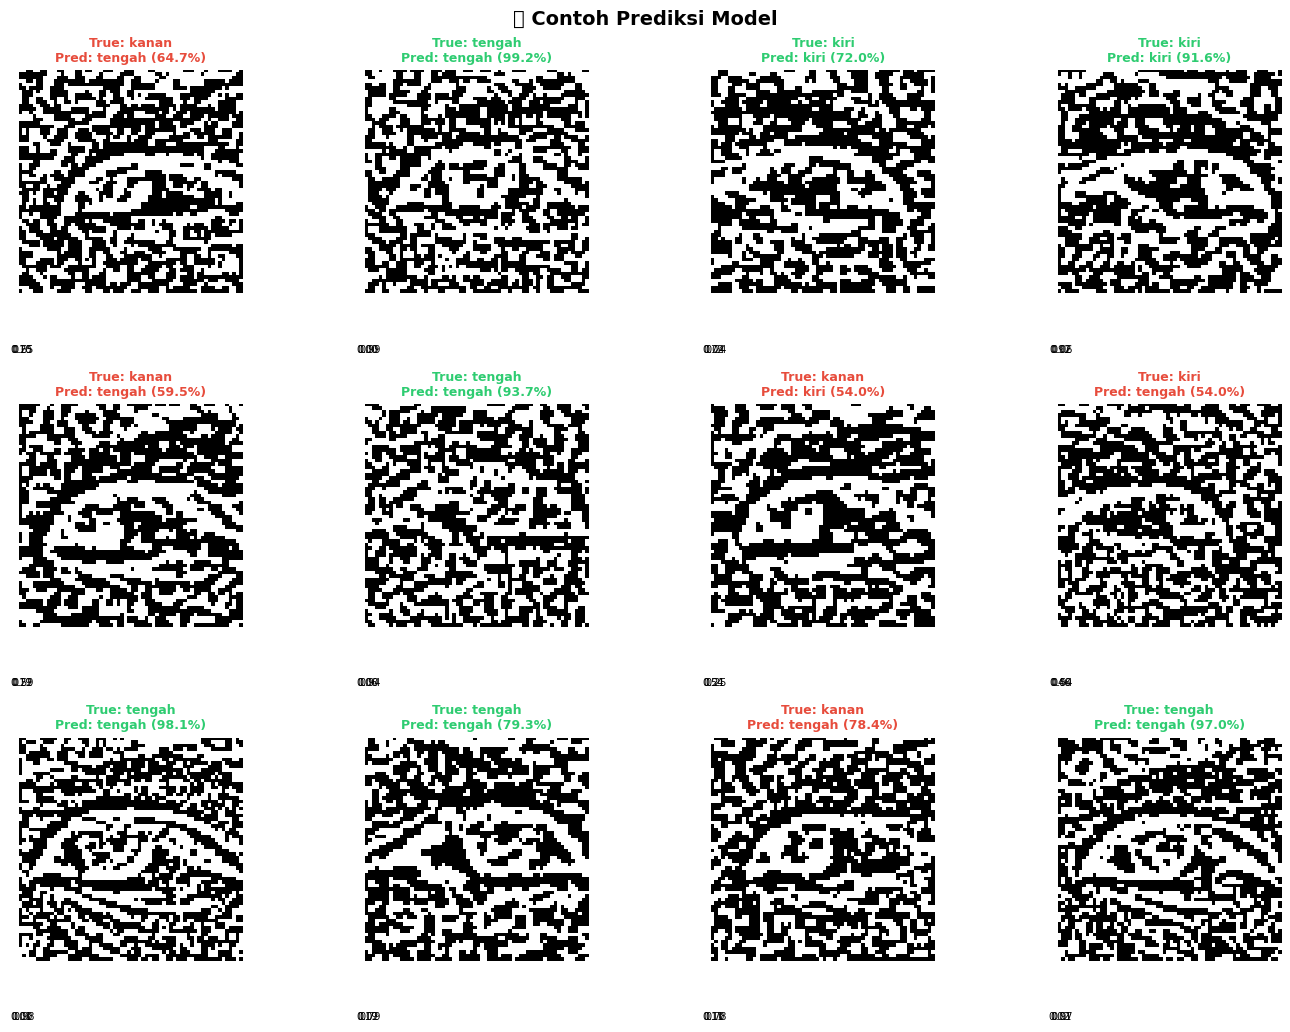

In [15]:
# ─── VISUALISASI 3: PREDIKSI SAMPLE ──────────────────────────────────────────
def visualize_predictions(X_data, y_true, y_pred_probs, n_samples=12):
    """Menampilkan contoh prediksi dengan probabilitas."""
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Pilih sampel acak
    indices = np.random.choice(len(X_data), n_samples, replace=False)
    
    rows = (n_samples + 3) // 4
    fig, axes = plt.subplots(rows, 4, figsize=(14, 3.5 * rows))
    axes = axes.flatten() if rows > 1 else [axes] if n_samples == 1 else axes
    
    for i, idx in enumerate(indices):
        ax = axes[i]
        img = X_data[idx].squeeze()
        true_label = CATEGORIES[y_true[idx]]
        pred_label = CATEGORIES[y_pred[idx]]
        confidence = y_pred_probs[idx][y_pred[idx]]
        
        # Warna border: hijau=benar, merah=salah
        color = '#2ecc71' if y_true[idx] == y_pred[idx] else '#e74c3c'
        
        ax.imshow(img, cmap='gray')
        ax.set_title(
            f"True: {true_label}\nPred: {pred_label} ({confidence:.1%})",
            color=color,
            fontweight='bold',
            fontsize=9
        )
        
        # Tambahkan bar probabilitas
        probs = y_pred_probs[idx]
        bar_y = -0.15
        bar_height = 0.08
        colors_bar = ['#3498db', '#e74c3c', '#2ecc71']
        
        for j, (p, c) in enumerate(zip(probs, colors_bar)):
            ax.barh(bar_y, p * 0.3, height=bar_height, left=j * 0.35, 
                    color=c, alpha=0.8, transform=ax.get_xaxis_transform())
            ax.text(j * 0.35 + p * 0.15, bar_y - bar_height, 
                    f'{p:.2f}', ha='center', va='top', fontsize=7, transform=ax.get_xaxis_transform())
        
        ax.axis('off')
    
    # Sembunyikan axes yang tidak terpakai
    for i in range(n_samples, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle("🖼️ Contoh Prediksi Model", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Tampilkan prediksi pada data test
visualize_predictions(X_test, y_test, y_pred, n_samples=12)

---

## 9. Prediksi pada Data Baru

**Fungsi untuk menggunakan model yang sudah dilatih untuk memprediksi arah pandangan mata pada gambar baru.**

In [16]:
# ─── FUNGSI PREDIKSI ──────────────────────────────────────────────────────────
def predict_gaze(image_path_or_array, model=None):
    """
    Memprediksi arah pandangan dari gambar mata.
    
    Parameters:
        image_path_or_array: Path ke file .npy atau array gambar
        model: Model yang sudah dilatih (default: model global)
    
    Returns:
        dict: {'label': str, 'confidence': float, 'probabilities': list}
    """
    if model is None:
        model = globals().get('model')
    
    # Load gambar
    if isinstance(image_path_or_array, str):
        img = np.load(image_path_or_array)
    else:
        img = image_path_or_array
    
    # Preprocessing
    if len(img.shape) == 2:
        img = img[np.newaxis, ..., np.newaxis]  # (H,W) → (1,H,W,1)
    elif len(img.shape) == 3:
        img = img[np.newaxis, ...]  # (H,W,1) → (1,H,W,1)
    
    # Prediksi
    probs = model.predict(img, verbose=0)[0]
    predicted_idx = np.argmax(probs)
    
    return {
        'label': CATEGORIES[predicted_idx],
        'confidence': float(probs[predicted_idx]),
        'probabilities': {cat: float(p) for cat, p in zip(CATEGORIES, probs)}
    }

# ─── DEMO PREDIKSI ────────────────────────────────────────────────────────────
print("=" * 60)
print("🔮 DEMO PREDIKSI PADA DATA TEST")
print("=" * 60 + "\n")

for i in range(5):
    idx = np.random.randint(len(X_test))
    result = predict_gaze(X_test[idx])
    true_label = CATEGORIES[y_test[idx]]
    
    status = "✅ BENAR" if result['label'] == true_label else "❌ SALAH"
    
    print(f"Sampel {i+1}:")
    print(f"  Prediksi  : {result['label'].upper()} ({result['confidence']:.2%})")
    print(f"  Aktual    : {true_label.upper()}")
    print(f"  Status    : {status}")
    print(f"  Probabilitas: {result['probabilities']}")
    print()

🔮 DEMO PREDIKSI PADA DATA TEST

Sampel 1:
  Prediksi  : TENGAH (90.33%)
  Aktual    : KANAN
  Status    : ❌ SALAH
  Probabilitas: {'kiri': 0.03930449113249779, 'kanan': 0.05739946290850639, 'tengah': 0.9032959938049316}

Sampel 2:
  Prediksi  : TENGAH (81.94%)
  Aktual    : KANAN
  Status    : ❌ SALAH
  Probabilitas: {'kiri': 0.07660507410764694, 'kanan': 0.10401862859725952, 'tengah': 0.8193762898445129}

Sampel 3:
  Prediksi  : KIRI (79.17%)
  Aktual    : KIRI
  Status    : ✅ BENAR
  Probabilitas: {'kiri': 0.791714072227478, 'kanan': 0.01709623821079731, 'tengah': 0.19118967652320862}

Sampel 4:
  Prediksi  : TENGAH (96.72%)
  Aktual    : TENGAH
  Status    : ✅ BENAR
  Probabilitas: {'kiri': 0.03021828457713127, 'kanan': 0.002628760877996683, 'tengah': 0.9671529531478882}

Sampel 5:
  Prediksi  : KIRI (97.89%)
  Aktual    : KIRI
  Status    : ✅ BENAR
  Probabilitas: {'kiri': 0.9788914322853088, 'kanan': 0.010824132710695267, 'tengah': 0.01028449647128582}



---

## 📝 Ringkasan

### Apa yang Sudah Kita Bangun:

1. **✅ Dataset Loading** - Memuat gambar grayscale 64x64 dari 3 folder kelas
2. **✅ Preprocessing** - Normalisasi dan penambahan dimensi channel
3. **✅ Data Augmentation** - Rotasi, shift, zoom, brightness untuk robustness
4. **✅ CNN Architecture** - 3 blok konvolusi (32→64→128) + fully connected
5. **✅ Training** - Adam optimizer, early stopping, model checkpoint
6. **✅ Evaluasi** - Accuracy, loss curves, confusion matrix, classification report

### File Output:
- `model/eye_tracker.h5` - Model terbaik (saved)
- `model/training_curves.png` - Kurva training
- `model/confusion_matrix.png` - Confusion matrix
- `model/architecture.png` - Diagram arsitektur

### Tips Penggunaan Model:
```python
# Load model yang sudah dilatih
from tensorflow.keras.models import load_model
model = load_model('model/eye_tracker.h5')

# Prediksi
result = predict_gaze('path/to/image.npy', model)
print(result['label'])  # 'kiri', 'kanan', atau 'tengah'
```

---

*Notebook ini dibuat untuk keperluan presentasi dan demonstrasi CNN untuk Eye Tracking.*